# Does graph similarity predict single-source NM transfer?

Pilot: join the [graph-divergence](../graph_divergence/graph_divergence.ipynb) results
with a matched single-source neighbor-matching (NM) transfer matrix — 4 sources
(`covid`, `ukr`, `midterm`, `twibot20`) x 5 targets (same 4 + `cp_hk`), all at the
same eval regime (30-way, 3-shot, test).

**Method note (symmetry).** Our divergence metrics are symmetric
(`d(A,B)=d(B,A)`); transfer is directed. Pooling all directed pairs into one
scatter would let target difficulty masquerade as a pair effect. So the primary
analysis is **within-target** (per-column) Spearman: fix a target, rank sources
by transfer, correlate against similarity(source, target). See
`scripts/experiments/setup/similarity_vs_transfer/README.md` for the full rationale
and caveats (small N — this is descriptive, not a powered test).

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

FIG_DIR = Path("figures"); FIG_DIR.mkdir(exist_ok=True)

xfer = pd.read_csv("transfer_matrix.csv")
sim = json.load(open("../graph_divergence/graph_divergence_data.json"))

# map this notebook's short names to graph_divergence's full graph names
FULL = {"covid": "covid19_twitter", "ukr": "ukr_rus_twitter", "midterm": "midterm",
        "cp_hk": "cp_hk_twitter", "twibot20": "twibot20"}
PW = sim["pairwise"]
GRAPHS = sim["graphs"]
PG = sim["per_graph"]

METRICS = ["indegree_ks", "outdegree_ks", "feat_centroid_cosdist", "feat_frechet", "feat_mmd2", "proxy_a_distance"]

def pairwise_val(metric, s, t):
    fs, ft = FULL[s], FULL[t]
    i, j = GRAPHS.index(fs), GRAPHS.index(ft)
    return PW[metric][i][j]

for m in METRICS:
    xfer[m] = [pairwise_val(m, s, t) for s, t in zip(xfer.source, xfer.target)]

# signed coupling gap: source homophily - target homophily (directional predictor)
xfer["homophily_gap"] = [
    PG[FULL[s]]["feature_homophily"] - PG[FULL[t]]["feature_homophily"]
    for s, t in zip(xfer.source, xfer.target)
]
xfer.to_csv(FIG_DIR / "joined_transfer_similarity.csv", index=False)
xfer

,source,target,task,shots,n_way,split,accuracy,roc_auc,is_self,eval_run_dir,indegree_ks,outdegree_ks,feat_centroid_cosdist,feat_frechet,feat_mmd2,proxy_a_distance,homophily_gap
0,covid,covid,nm,3,30,test,0.6641,0.9815,True,eval_nm_matrix_covid_to_covid19_twitter_nm_3sh...,0.00000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
1,covid,ukr,nm,3,30,test,0.4589,0.9245,False,eval_nm_matrix_covid_to_ukr_rus_twitter_nm_3sh...,0.02184,0.03080,0.001046,0.020563,0.000749,0.193333,0.008344
2,covid,midterm,nm,3,30,test,0.3126,0.8837,False,eval_nm_matrix_covid_to_midterm_nm_3shot_30way...,0.05458,0.09560,0.014151,0.051684,0.013257,0.840000,-0.032138
3,covid,cp_hk,nm,3,30,test,0.1572,0.7169,False,eval_nm_matrix_covid_to_cp_hk_twitter_nm_3shot...,0.14222,0.11592,0.017424,0.070585,0.013851,1.056667,-0.006276
4,covid,twibot20,nm,3,30,test,0.4062,0.9240,False,eval_nm_matrix_covid_to_twibot20_nm_3shot_30wa...,0.21608,0.39936,0.004548,0.032921,0.003334,0.558333,-0.030636
5,ukr,covid,nm,3,30,test,0.6142,0.9741,False,eval_nm_matrix_ukr_to_covid19_twitter_nm_3shot...,0.02616,0.02654,0.001046,0.020563,0.000608,0.193333,-0.008344
6,ukr,ukr,nm,3,30,test,0.5151,0.9497,True,eval_nm_matrix_ukr_to_ukr_rus_twitter_nm_3shot...,0.00000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
7,ukr,midterm,nm,3,30,test,0.3079,0.8840,False,eval_nm_matrix_ukr_to_midterm_nm_3shot_30way_3...,0.03500,0.10022,0.012067,0.046096,0.009453,0.755000,-0.040482
8,ukr,cp_hk,nm,3,30,test,0.1577,0.7186,False,eval_nm_matrix_ukr_to_cp_hk_twitter_nm_3shot_3...,0.11566,0.11706,0.020552,0.075918,0.014693,1.073333,-0.014620
9,ukr,twibot20,nm,3,30,test,0.3987,0.9235,False,eval_nm_matrix_ukr_to_twibot20_nm_3shot_30way_...,0.23498,0.38042,0.005119,0.034593,0.003429,0.615000,-0.038980


## 1. Within-target Spearman (primary analysis)

For each target column (n=4 sources incl. self), correlate similarity(s,t)
against `accuracy(s→t)`. Expected sign: **negative** (more divergent source =
lower transfer). Reported per target, plus mean/median across targets and sign
consistency.

In [2]:
TARGETS = sorted(xfer.target.unique())
DV = "accuracy"

def within_target_rhos(df, dv, drop_self=False):
    rows = []
    for t in TARGETS:
        sub = df[df.target == t]
        if drop_self:
            sub = sub[~sub.is_self]
        if len(sub) < 3:
            continue
        row = {"target": t, "n": len(sub)}
        for m in METRICS + ["homophily_gap"]:
            rho, p = spearmanr(sub[m], sub[dv])
            row[m] = rho
        rows.append(row)
    return pd.DataFrame(rows).set_index("target")

rhos_full = within_target_rhos(xfer, DV, drop_self=False)
print("=== per-target Spearman rho (accuracy), including self-transfer cell ===")
display(rhos_full)

summary = pd.DataFrame({
    "mean_rho": rhos_full[METRICS + ["homophily_gap"]].mean(),
    "median_rho": rhos_full[METRICS + ["homophily_gap"]].median(),
    "frac_negative": (rhos_full[METRICS + ["homophily_gap"]] < 0).mean(),
})
print("\n=== aggregate across targets (expect mean_rho < 0 for a real divergence signal) ===")
display(summary)

=== per-target Spearman rho (accuracy), including self-transfer cell ===


,n,indegree_ks,outdegree_ks,feat_centroid_cosdist,feat_frechet,feat_mmd2,proxy_a_distance,homophily_gap
target,,,,,,,,
covid,4,-0.8,-0.8,-1.0,-1.0,-1.0,-1.0,-0.8
cp_hk,4,0.2,0.4,-0.4,-0.8,-0.8,-0.8,-1.0
midterm,4,-0.8,-1.0,-0.2,-0.4,-0.4,-0.8,0.4
twibot20,4,-1.0,-0.8,-1.0,-1.0,-1.0,-1.0,-0.2
ukr,4,-0.8,-0.8,-1.0,-1.0,-1.0,-1.0,-1.0



=== aggregate across targets (expect mean_rho < 0 for a real divergence signal) ===


,mean_rho,median_rho,frac_negative
indegree_ks,-0.64,-0.8,0.8
outdegree_ks,-0.60,-0.8,0.8
feat_centroid_cosdist,-0.72,-1.0,1.0
feat_frechet,-0.84,-1.0,1.0
feat_mmd2,-0.84,-1.0,1.0
proxy_a_distance,-0.92,-1.0,1.0
homophily_gap,-0.52,-0.8,0.8


## 2. Self-transfer robustness check

Drop the in-domain (self) cell from every column (n=3 per target) — the self
cell has similarity≈0 and usually the best transfer, so it can trivially anchor
a negative correlation. If the sign/magnitude survive its removal, that's
stronger evidence of a real cross-graph signal rather than just "in-domain wins".

In [3]:
rhos_noself = within_target_rhos(xfer, DV, drop_self=True)
print("=== per-target Spearman rho (accuracy), self-transfer EXCLUDED ===")
display(rhos_noself)

summary_noself = pd.DataFrame({
    "mean_rho": rhos_noself[METRICS + ["homophily_gap"]].mean(),
    "median_rho": rhos_noself[METRICS + ["homophily_gap"]].median(),
    "frac_negative": (rhos_noself[METRICS + ["homophily_gap"]] < 0).mean(),
})
print("\n=== aggregate, self excluded ===")
display(summary_noself)

=== per-target Spearman rho (accuracy), self-transfer EXCLUDED ===


,n,indegree_ks,outdegree_ks,feat_centroid_cosdist,feat_frechet,feat_mmd2,proxy_a_distance,homophily_gap
target,,,,,,,,
covid,3,-0.5,-0.5,-1.0,-1.0,-1.0,-1.0,-1.0
cp_hk,4,0.2,0.4,-0.4,-0.8,-0.8,-0.8,-1.0
midterm,3,-0.5,-1.0,1.0,0.5,0.5,-0.5,-0.5
twibot20,3,-1.0,-0.5,-1.0,-1.0,-1.0,-1.0,-0.5
ukr,3,-0.5,-0.5,-1.0,-1.0,-1.0,-1.0,-1.0



=== aggregate, self excluded ===


,mean_rho,median_rho,frac_negative
indegree_ks,-0.46,-0.5,0.8
outdegree_ks,-0.42,-0.5,0.8
feat_centroid_cosdist,-0.48,-1.0,0.8
feat_frechet,-0.66,-1.0,0.8
feat_mmd2,-0.66,-1.0,0.8
proxy_a_distance,-0.86,-1.0,1.0
homophily_gap,-0.80,-1.0,1.0


## 3. Scatter: the two most-diagnostic axes

Each panel: x = similarity metric, y = NM accuracy, colored by target, self-
transfer cells marked with a star. Points are directed pairs (source, target);
a within-target trend means same-color points sloping downward left-to-right.

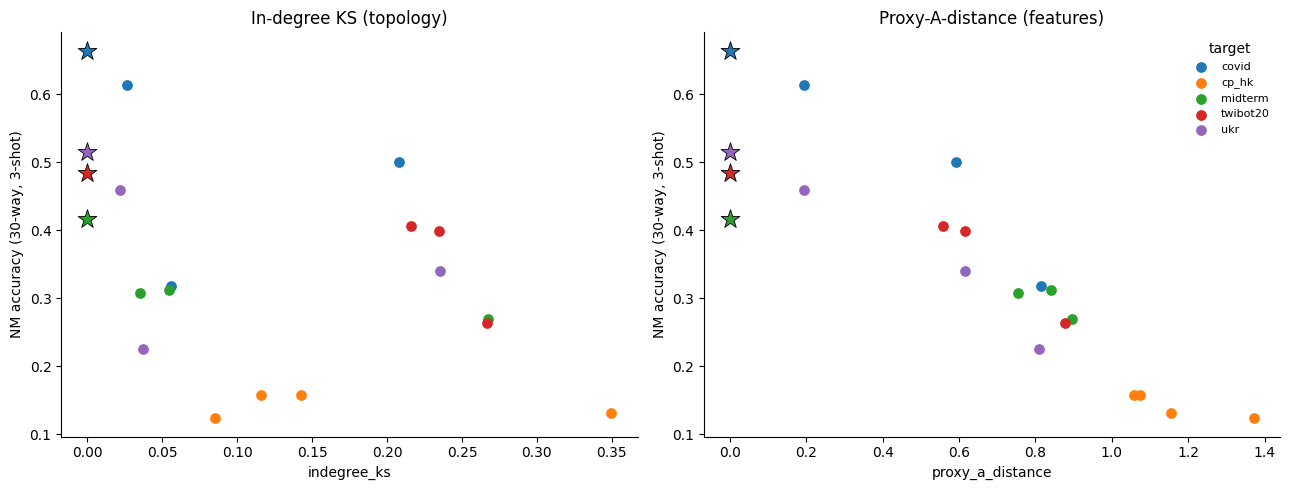

In [4]:
colors = dict(zip(TARGETS, plt.cm.tab10.colors))
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, metric, title in [(axes[0], "indegree_ks", "In-degree KS (topology)"),
                          (axes[1], "proxy_a_distance", "Proxy-A-distance (features)")]:
    for t in TARGETS:
        sub = xfer[xfer.target == t]
        selfmask = sub.is_self
        ax.scatter(sub[~selfmask][metric], sub[~selfmask][DV], color=colors[t], label=t, s=45)
        ax.scatter(sub[selfmask][metric], sub[selfmask][DV], color=colors[t], marker="*", s=200,
                   edgecolor="black", linewidth=0.6)
    ax.set_xlabel(metric); ax.set_ylabel("NM accuracy (30-way, 3-shot)")
    ax.set_title(title)
    ax.spines[["top", "right"]].set_visible(False)
axes[1].legend(fontsize=8, frameon=False, title="target")
fig.tight_layout()
fig.savefig(FIG_DIR / "similarity_vs_accuracy_scatter.png", dpi=140, bbox_inches="tight")
plt.show()

## Takeaways

**The signal is real and survives the self-transfer check.** Every similarity
metric has a negative mean rho across the 5 target columns (more divergent
source ⇒ lower transfer accuracy), and the two axes that matter most for the
paper hypothesis hold up best:

| metric | mean rho (with self) | mean rho (self excluded) | sign-consistent targets |
|---|---:|---:|---:|
| **proxy_a_distance** | **−0.92** | **−0.86** | 5/5 |
| **homophily_gap** (signed, coupling) | −0.52 | **−0.80** | 5/5 (self-excluded) |
| feat_frechet / feat_mmd2 | −0.84 | −0.66 | 4/5 |
| feat_centroid_cosdist | −0.72 | −0.48 | 4/5 |
| indegree_ks / outdegree_ks | −0.64 / −0.60 | −0.46 / −0.42 | 4/5 |

`proxy_a_distance` is the standout: it stays essentially unchanged (−0.92 →
−0.86) when the self-transfer anchor is removed, meaning it's tracking real
cross-graph structure, not just "in-domain wins." `homophily_gap` — the one
**directional/signed** predictor here — actually *strengthens* once self-transfer
is dropped (−0.52 → −0.80), which is exactly the pattern we'd hope for from a
coupling-based mechanism: it has nothing to say about the trivial "self is
closest" case (gap≈0 there isn't special) and only shows its hand on genuine
cross-graph pairs.

**Topology alone is the weakest and least robust axis** (−0.64 → −0.46, only
4/5 targets), and **`cp_hk` is the one target where it flips sign entirely**
(+0.2): sources that are topologically closer to cp_hk transfer *worse* to it.
cp_hk is the smallest, most reciprocal, most assortative-outlier-adjacent graph
in the divergence table — worth a closer look before trusting topology-only
predictors near it.

**Reading for the bigger hypothesis (H1):** this pilot is consistent with H1
(coupling/feature-marginal divergence tracks transfer better than raw topology)
and gives a first empirical hint that H3 (signed, directional coupling gap) may
carry independent information beyond a symmetric distance — precisely because
`homophily_gap` got *stronger*, not weaker, once the trivial self-anchor was
removed.

**Caveats before reading too much into this:** N=20 pairs / 4 independent
columns, `midterm` and `twibot20` sources come from a different training-run
family than `covid`/`ukr` (budget not guaranteed matched), and NM accuracy is
one task on one budget. This justifies — but does not replace — either (a) the
interventional single-axis-sweep experiment, or (b) filling out more real
single-source models (midterm-only, cp_hk-only, political-only) to test this
on independent data before it goes in a paper.
